<h1 style="color:#c8a2c8; font-weight:bold; margin-bottom: 0px; padding-bottom: 0px;">ImmoEliza Project</h1>  
<h2 style="color:#c8a2c8; margin-top: 0px; padding-top: 0px;">ML content</h2>

<i><span style="color:orange">Note for the 03/07:</span> try to make all checking prints not blind.</i>

<h3 style="color:#c8a2c8; font-weight:bold; margin-bottom: 0px; padding-bottom: 0px;">3 - Baseline Model</h3>  
<u><h3 style="color:#c8a2c8; margin-top: 0px; padding-top: 0px; margin-bottom: 0px; padding-bottom: 0px;">Multiple Linear Regression</h3></u>

<h3 style="font-weight:bold; margin-bottom: 0px; padding-bottom: 0px;">Historical and Programmatic reference point for the project</h3>

In [1]:
# import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# other sklearn imports
from sklearn.base import BaseEstimator, TransformerMixin

print("✅ Libraries setup complete.")

✅ Libraries setup complete.


In [2]:
# file location dygnosis
print(f"⚠️ Python is reading from here:\n{os.getcwd()}.")

⚠️ Python is reading from here:
d:\Irene\Desktop\AI_&_Data_Science_training_BeCode\BeCode Projects\Preparation-for-Sprint-3-IMMO-ELIZA-Project\3_Baseline_Model\02-ModelingStructuredData.


In [3]:
# importing features train and test preprocessed datasets

PROP_TRAIN_PREPROC_CSV_PATH = "../../data/cleaned/properties_train_preprocessed.csv"
PROP_TEST_PREPROC_CSV_PATH = "../../data/cleaned/properties_test_preprocessed.csv"

X_train = pd.read_csv(PROP_TRAIN_PREPROC_CSV_PATH)
X_test = pd.read_csv(PROP_TEST_PREPROC_CSV_PATH)

print("✅ Preprocessed dataset for Train 'properties_train' successfully loaded.")
print("✅ Preprocessed dataset for Test 'properties_test' successfully loaded.")

✅ Preprocessed dataset for Train 'properties_train' successfully loaded.
✅ Preprocessed dataset for Test 'properties_test' successfully loaded.


In [4]:
# importing target train and test datasets

Y_TRAIN_CSV_PATH = "../../data/raw/train_test/y_train.csv"
Y_TEST_CSV_PATH = "../../data/raw/train_test/y_test.csv"

y_train = pd.read_csv(Y_TRAIN_CSV_PATH)
y_test = pd.read_csv(Y_TEST_CSV_PATH)

print("✅ Target dataset for Train 'target_train' successfully loaded.")
print("✅ Target dataset for Test 'target_test' successfully loaded.")

✅ Target dataset for Train 'target_train' successfully loaded.
✅ Target dataset for Test 'target_test' successfully loaded.


**Excluding outliers** from both Train and Test

In [5]:
# temporarly reallign target with features
train_temp = X_train.copy()
train_temp['price'] = y_train.values 

# apply thresholds (removing lower and upper 1%)
q_low = train_temp['price'].quantile(0.01)
q_high = train_temp['price'].quantile(0.99)

# filter dataset
train_filtered = train_temp[(train_temp['price'] > q_low) & (train_temp['price'] < q_high)]

# splittingn again xfiltered X and y before training
X_train_clean = train_filtered.drop(columns=['price'])
y_train_clean = train_filtered['price']

<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">3.1 - Training</h3>

**Model training**

In [6]:
# Initialization
# alpha=1.0 is the standard parameter for balancing regularization
regressor_model = Ridge(alpha=1.0) # model_name

# Train
X_train_clean
y_train_clean

# Test
X_test
y_test

# model training
regressor_model.fit(X_train_clean, y_train_clean)

print("✅ Ridge Regression model successfully trained on features in properties_train_preproc and target in target_train.")

✅ Ridge Regression model successfully trained on features in properties_train_preproc and target in target_train.


**Model Efficiency Check**

In [7]:
# model parameters extraction
b0 = regressor_model.intercept_
b1 = regressor_model.coef_

print(f'Model Intercept (b0): {b0}')
print(f'Model coefficients (b1): {b1}')

# calculating model performance score R²
train_r2 = regressor_model.score(X_train_clean, y_train_clean)

print(f"Train Score (R²): {round((train_r2 * 100), 2)} %.")


Model Intercept (b0): 390962.69795541983
Model coefficients (b1): [-5.19184117e+04  6.01786904e+04  4.74785929e+04  6.52600313e+04
 -5.95047861e+00  5.47753285e+04  1.67062515e+04  9.17726510e+03
  7.24299752e+03 -1.25627380e+03  2.39026498e+04 -9.81649570e+02
  4.53654937e+03  2.25670253e+04  3.25963038e+04 -1.04543851e+04
  1.14348074e+04  1.37204686e+04  1.66053831e+04  4.08758282e+04
  5.30343999e+03 -9.77295215e+03  1.19715334e+05 -1.84145308e+03
  1.72423441e+05 -1.01259544e+04 -9.17726510e+03  3.04127314e+03
 -3.31769243e+04  4.34335316e+03 -4.31765251e+04 -8.40420171e+04
 -6.98474191e+04 -4.86432267e+04 -3.48635609e+03 -4.39464830e+04
  2.00466274e+04  1.54240308e+05  8.33584910e+04 -7.30352859e+03
  1.32095142e+05 -4.60532512e+04 -1.55662508e+05  4.22116911e+04
  7.02090556e+04  3.10294137e+04 -2.46023355e+03 -2.85691801e+04
 -2.28202773e+04  3.10294137e+04  4.61239477e+04  2.69340429e+04
 -2.80007836e+04 -8.03301644e+04 -4.65247371e+04  3.46090398e+04
 -1.53322146e+04  2.6679

<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">3.2 - Prediction</h3>

**Prediction**

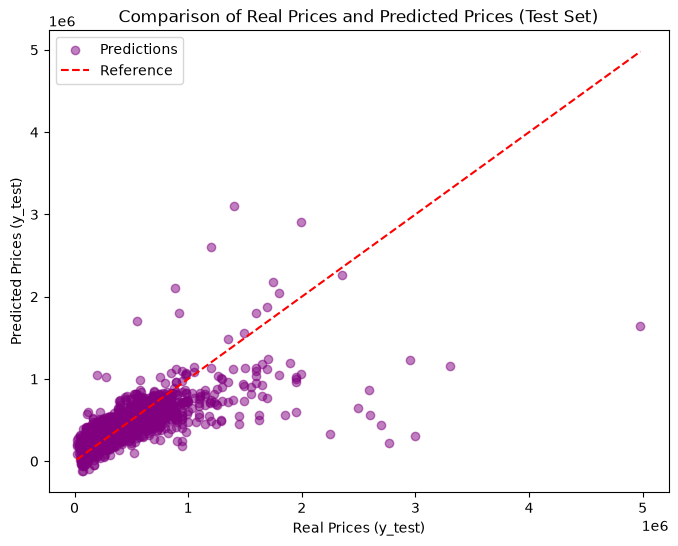

Test score is 52.07 %.
Switching to Test, there is a drop in performance of approximately 12.32 %.


In [8]:
# using .predict()
y_prediction_test = regressor_model.predict(X_test)

# plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_prediction_test, color='purple', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Reference')

plt.xlabel('Real Prices (y_test)')
plt.ylabel('Predicted Prices (y_test)')
plt.title('Comparison of Real Prices and Predicted Prices (Test Set)')
plt.legend()
plt.show()

# checking score on X_test and y_test
test_r2 = regressor_model.score(X_test, y_test)

print(f'Test score is {round(((test_r2) * 100), 2)} %.')
print(f'Switching to Test, there is a drop in performance of approximately {round((((train_r2 - test_r2) / train_r2) * 100), 2)} %.')

Ridge seems to return an acceptable estimate for price of stanard market properties.  
But as price gets higher, the purple points tend to deviate markedly from the red line, with **almost all of them positioned below** it.  

This means there is **Underfitting** on high prices &rarr; need to switch to non-linear models, such as <span style="color:#c8a2c8; font-weight:bold;">Random Forest</span>, in the next notebook

<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">3.3 - Absolute Error Metrics</h3>

To calculate error in euro of the model &rarr; **MAE** (Mean Absolute Error) and **RMSE** (Root Mean Squared Error).

In [9]:
# prediction on Train
y_prediction_train = regressor_model.predict(X_train_clean)

# calculate metrics for Train
mae_train = mean_absolute_error(y_train_clean, y_prediction_train)
rmse_train = np.sqrt(mean_squared_error(y_train_clean, y_prediction_train))

# calculate metrics for Test
mae_test = mean_absolute_error(y_test, y_prediction_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_prediction_test))

print(f"📊 Train -> MAE: {mae_train:,.2f} € | RMSE: {rmse_train:,.2f} €")
print(f"📊 Test -> MAE: {mae_test:,.2f} € | RMSE: {rmse_test:,.2f} €")


📊 Train -> MAE: 107,141.96 € | RMSE: 162,811.07 €
📊 Test -> MAE: 119,304.77 € | RMSE: 227,535.90 €


<i><span style="color:green">DONE:</span> put calculation of Train R2, Train MAE, Test R2, Test MAE in a function that returns them as a dictionary with key 'Ridge (Baseline)' string and value a dictionary with keys the metrics and values the relative values &rarr; will be called at the beginning of the Model Comparison notebook.</i>

In [10]:
def calculate_metrics(X_train, y_train, X_test, y_test):
    '''
    returns a string containing R2 and MAE for both Train and Test.
    '''
    # R²
    train_r2 = regressor_model.score(X_train, y_train)
    test_r2 = regressor_model.score(X_test, y_test)

    # MAE
    y_prediction_train = regressor_model.predict(X_train)
    y_prediction_test = regressor_model.predict(X_test)
    mae_train = mean_absolute_error(y_train, y_prediction_train)
    mae_test = mean_absolute_error(y_test, y_prediction_test)

    return f'The model has the following error metrics:\nR² -> Train: {round((train_r2 * 100), 2)} % | Test: {round((test_r2 * 100), 2)} %\nMAE -> Train: {mae_train:,.2f} € | Test: {mae_test:,.2f} €'

In [11]:
print(calculate_metrics(X_train_clean, y_train_clean, X_test, y_test))

The model has the following error metrics:
R² -> Train: 59.39 % | Test: 52.07 %
MAE -> Train: 107,141.96 € | Test: 119,304.77 €


<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">3.4 - Residual Analysis</h3>

In [12]:
# verify objects shape
print(f'y_test type & shape: {type(y_test), y_test.shape}')
print(f'y_prediction_test type & shape: {type(y_prediction_test), y_prediction_test.shape}')

y_test type & shape: (<class 'pandas.DataFrame'>, (2480, 1))
y_prediction_test type & shape: (<class 'numpy.ndarray'>, (2480,))


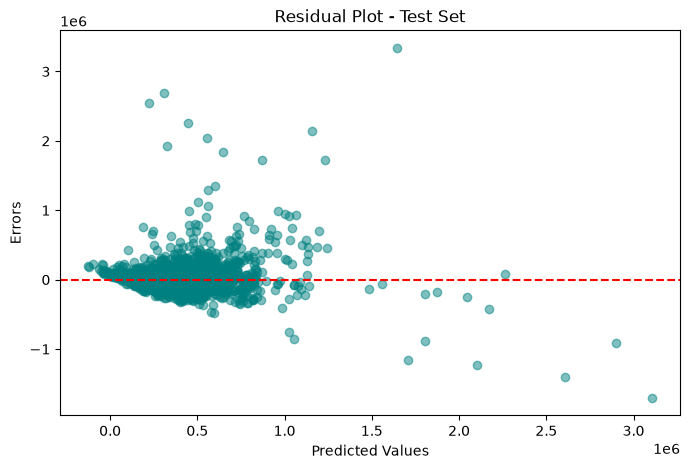

In [13]:
# calculate residuals
# excract first (and only) column of 2D y_test
resid_test = y_test.iloc[:, 0] - y_prediction_test

# plot
plt.figure(figsize=(8,5))
plt.scatter(y_prediction_test, resid_test, color='teal', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Errors')
plt.title('Residual Plot - Test Set')
plt.show()

- The error variance is not constant. This means the model is not uniformly accurate: it is moderately reliable for low-priced homes but becomes increasingly unstable and blind as the property value rises.  

- The model suffers from a systematic bias in the luxury segment. A straight line lacks the flexibility to curve upwards as prices rise exponentially; consequently, it "cuts straight across," grossly underestimating the most expensive properties.  

- If the linear model were extracting all the useful signal from the data, the residuals would appear as white noise: a shapeless, symmetrical, and purely random cloud around the red zero line. The fact that there is such a distinct geometric pattern demonstrates that there is still information in the data that the model is failing to capture, because it is attempting to force a linear logic onto a market that is not linear.

I now have enough information to **close the Baseline Model notebook and move on to a new model**.

Saveing in CSV Train feature and target cleaned from outliers

In [14]:
X_TRAIN_CLEAN_CSV_PATH = "../../data/cleaned/X_train_clean.csv"
Y_TRAIN_CLEAN_CSV_PATH = "../../data/cleaned/y_train_clean.csv"

X_train_clean.to_csv(X_TRAIN_CLEAN_CSV_PATH, index=False)
y_train_clean.to_csv(Y_TRAIN_CLEAN_CSV_PATH, index=False)

print(f'✅ Train dataset cleaned from outliers successfully saved as "X_train_clean.csv" in {X_TRAIN_CLEAN_CSV_PATH}')
print(f'✅ Test dataset cleaned from outliers successfully saved as "y_train_clean.csv" in {Y_TRAIN_CLEAN_CSV_PATH}')

✅ Train dataset cleaned from outliers successfully saved as "X_train_clean.csv" in ../../data/cleaned/X_train_clean.csv
✅ Test dataset cleaned from outliers successfully saved as "y_train_clean.csv" in ../../data/cleaned/y_train_clean.csv
